# Imports

In [45]:
import torch
from torch.nn import CrossEntropyLoss
from segmentation_models_pytorch.losses import DiceLoss
from torch.utils.data import DataLoader
from torchvision import transforms
from RuralDataset import RuralDataset
from SegmentationModel import SegmentationModel
from Trainer import Trainer
from Evaluator import Evaluator

torch.cuda.empty_cache()

# Configuration parameters

In [46]:
DATA_ROOT = 'train'
BATCH_SIZE = 16
LEARNING_RATE = 0.0001
NUM_EPOCHS = 50
NUM_CLASSES = 9
MODEL_SAVE_PATH = 'saved_model.pth'

# Device configuration

In [47]:
if torch.cuda.is_available():
    device = torch.device('cuda')  # Configura per utilizzare la GPU
    print(f"Utilizzo GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device('cpu')  # Fallback alla CPU
    print("CUDA non disponibile, utilizzo CPU")

Utilizzo GPU: NVIDIA GeForce RTX 5070 Ti


# Transforms initialization

In [48]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(512, scale=(0.8, 1.0), ratio=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05), shear=5),
    transforms.RandomPerspective(distortion_scale=0.1, p=0.3),
    transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
val_transform = transforms.Compose([
    transforms.Resize((512,512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Dataset loading and splitting into training and validation sets

In [49]:
# Crea dataset separati con le rispettive trasformazioni
from torch.utils.data import random_split

# Applica la trasformazione di training e validazione ai rispettivi dataset
full_dataset = RuralDataset(root_dir=DATA_ROOT, augment=True)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

# Suddividi il dataset in train e val
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Applica le trasformazioni ai sotto-dataset
# NOTA: random_split restituisce Subset, quindi bisogna settare la transform manualmente
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, num_workers=16, shuffle=True,
    pin_memory=True)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, num_workers=16, shuffle=False,
    pin_memory=True)

print(f"Training on {len(train_dataset)} samples, validating on {len(val_dataset)} samples.")

Training on 2979 samples, validating on 745 samples.


# Model initialization

In [50]:
model = SegmentationModel(NUM_CLASSES)
model.to(device)
print("Model architecture:")
print(model)

Model architecture:
SegmentationModel(
  (model): Unet(
    (encoder): ResNetEncoder(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=F

# Loss Function and optimizer definition

In [54]:
#weights =[ 3.8332,  1.0790,  0.7218,  0.7481,  0.8233,  0.3108,  1.7673, 70.4379, 12.8048]
weights = Trainer.compute_class_weights(train_loader, num_classes=NUM_CLASSES)
# Definizione della funzione di loss combinata
cross_entropy = CrossEntropyLoss(weight=weights.to(device))
dice_loss = DiceLoss(mode='multiclass')
def combined_loss(pred, target):
    return cross_entropy(pred, target) + dice_loss(pred, target)
criterion = combined_loss

In [52]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Trainer initialization and training

In [53]:
trainer = Trainer(model, train_loader, val_loader, criterion, optimizer, device)
print("\nStarting training...")
trainer.run(num_epochs=NUM_EPOCHS, model_save_path=MODEL_SAVE_PATH)
print("Training finished.")


Starting training...

Epoch 1/50
Batch 1/187, Loss: 3.3638
Batch 2/187, Loss: 3.2833
Batch 3/187, Loss: 3.3022
Batch 4/187, Loss: 3.1555
Batch 5/187, Loss: 3.1136
Batch 6/187, Loss: 2.9429
Batch 7/187, Loss: 3.1115
Batch 8/187, Loss: 2.9869
Batch 9/187, Loss: 2.9337
Batch 10/187, Loss: 2.7660
Batch 11/187, Loss: 2.7515
Batch 12/187, Loss: 3.0046
Batch 13/187, Loss: 2.7553
Batch 14/187, Loss: 2.8773
Batch 15/187, Loss: 2.7643
Batch 16/187, Loss: 2.5532
Batch 17/187, Loss: 2.6253
Batch 18/187, Loss: 2.6925
Batch 19/187, Loss: 2.7155
Batch 20/187, Loss: 2.8460
Batch 21/187, Loss: 2.4978
Batch 22/187, Loss: 2.8315
Batch 23/187, Loss: 2.4081
Batch 24/187, Loss: 2.6945
Batch 25/187, Loss: 2.4713
Batch 26/187, Loss: 2.6552
Batch 27/187, Loss: 2.4684
Batch 28/187, Loss: 2.4039
Batch 29/187, Loss: 2.3632
Batch 30/187, Loss: 2.6083
Batch 31/187, Loss: 2.5175
Batch 32/187, Loss: 2.3978
Batch 33/187, Loss: 2.2676
Batch 34/187, Loss: 2.6832
Batch 35/187, Loss: 2.4255
Batch 36/187, Loss: 2.6200
Bat

KeyboardInterrupt: 

# Model evaluation

In [10]:
model.load_state_dict(torch.load(MODEL_SAVE_PATH))

evaluator = Evaluator(model, val_loader, device)
metrics = evaluator.evaluate_classification_metrics()

# Example Predict

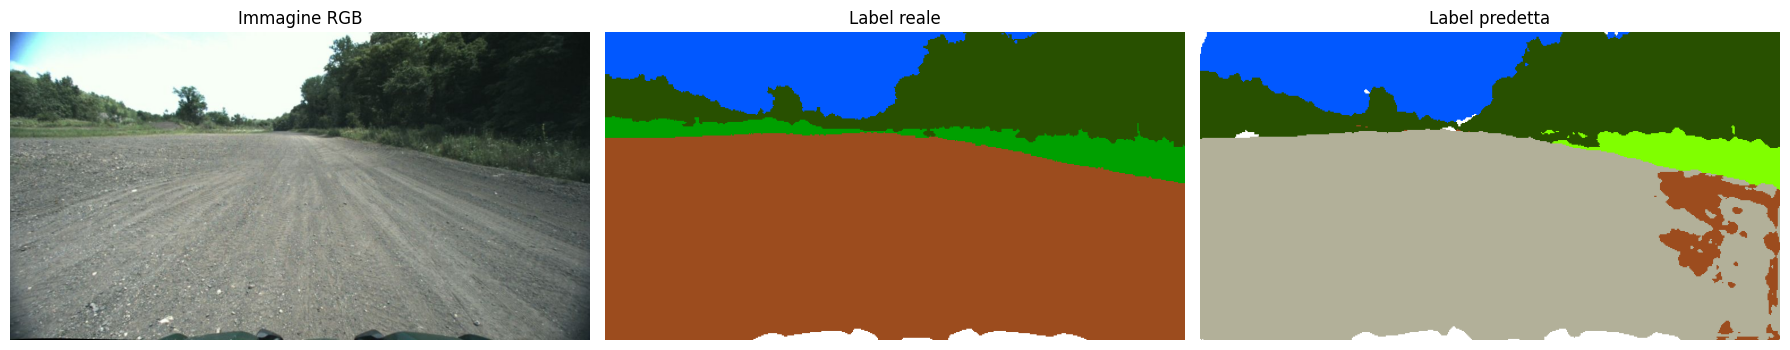

Pixel classificati correttamente: 49262 / 139264 (35.37%)
IoU medio sull'immagine: 0.3121
IoU per classe: [0.95408485 0.05915073 0.         0.         0.85916323 0.
        nan        nan]


In [36]:
evaluator.predict_from_folder(folder_number = 153)

In [12]:
print(metrics.get('accuracy', 'N/A'))
print(metrics.get('f1_score', 'N/A'))
print(metrics.get('precision', 'N/A'))
print(metrics.get('recall', 'N/A'))

0.9767523746362469
N/A
0.951536141023267
0.9796681993383471
